https://cobusgreyling.medium.com/tree-of-thoughts-prompting-tot-08555b04123e

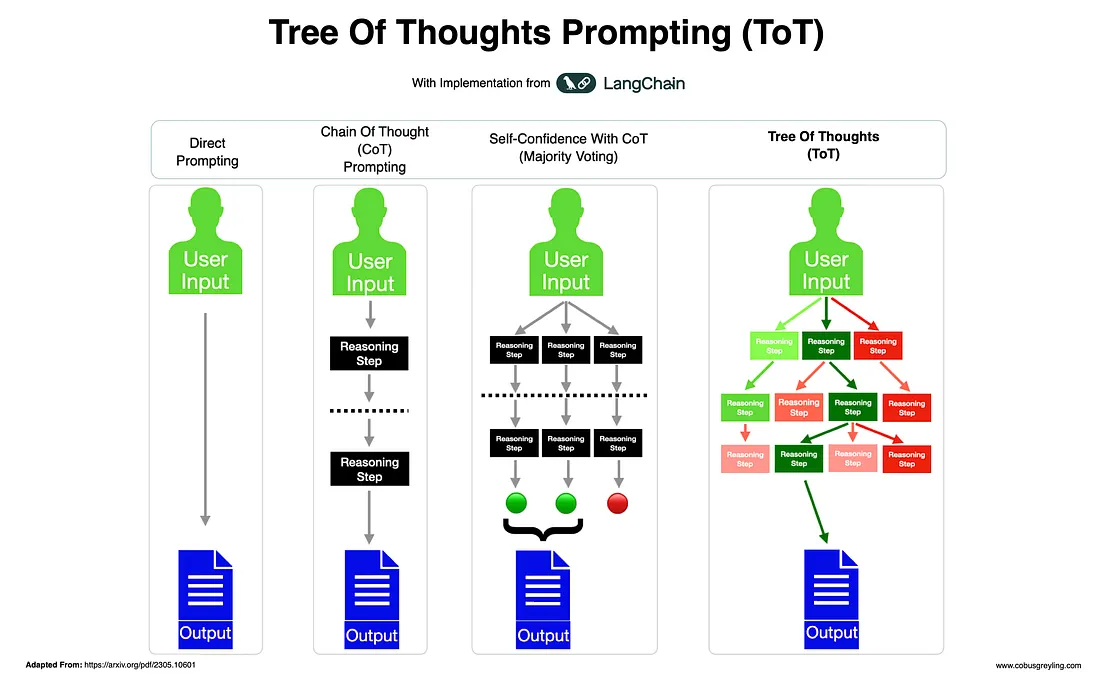

In [1]:
import os
import os
import re
from dotenv import load_dotenv
from langchain_openai import OpenAI
from typing import Tuple

from langchain_experimental.tot.base import ToTChain
from langchain_experimental.tot.checker import ToTChecker
from langchain_experimental.tot.thought import ThoughtValidity

load_dotenv(os.path.join("..", ".env"), override=True)

True

In [2]:
llm = OpenAI(temperature=0, model="gpt-4o-mini")

In [3]:
sudoku_puzzle =   "3,*,*,2|1,*,3,*|*,1,*,3|4,*,*,1"
sudoku_solution = "3,4,1,2|1,2,3,4|2,1,4,3|4,3,2,1"
problem_description = f"""
{sudoku_puzzle}
- This is a 4x4 Sudoku puzzle.
- The * represents a cell to be filled.
- The | character separates rows.
- At each step, replace one or more * with digits 1-4.
- There must be no duplicate digits in any row, column or 2x2 subgrid.
- Keep the known digits from previous valid thoughts in place.
- Each thought can be a partial or the final solution.

OUTPUT FORMAT:
Your thought must be ONLY the current state of the entire board in the format: 
D,D,D,D|D,D,D,D|D,D,D,D|D,D,D,D
Replace one or more '*' with a digit in each step.
""".strip()

print(problem_description)

3,*,*,2|1,*,3,*|*,1,*,3|4,*,*,1
- This is a 4x4 Sudoku puzzle.
- The * represents a cell to be filled.
- The | character separates rows.
- At each step, replace one or more * with digits 1-4.
- There must be no duplicate digits in any row, column or 2x2 subgrid.
- Keep the known digits from previous valid thoughts in place.
- Each thought can be a partial or the final solution.

OUTPUT FORMAT:
Your thought must be ONLY the current state of the entire board in the format: 
D,D,D,D|D,D,D,D|D,D,D,D|D,D,D,D
Replace one or more '*' with a digit in each step.


In [11]:
class MyChecker(ToTChecker):
    
    def evaluate(self, problem_description: str, thoughts: Tuple[str, ...] = ()) -> ThoughtValidity:
        
        if not thoughts:
            return ThoughtValidity.INVALID
            
        last_thought = thoughts[-1]
        
        # 1. Limpiamos AMBAS cadenas de espacios, comillas y saltos de línea
        clean_thought = last_thought.replace(" ", "").replace('"', "").strip()
        target_solution = sudoku_solution.replace(" ", "").strip()
        
        # 2. Si es idéntico a la solución, es el final
        if clean_thought == target_solution:
            return ThoughtValidity.VALID_FINAL
            
        # 3. Construimos el regex de forma segura:
        # Reemplazamos '*' por '[1-4]' para que solo valide números
        # Escapamos los caracteres especiales del pensamiento original (como el '|')
        regex_pattern = re.escape(clean_thought).replace(r"\*", r"[1-4]")
        
        # 4. Usamos fullmatch para asegurar que toda la cadena encaja
        if re.fullmatch(regex_pattern, target_solution):
            return ThoughtValidity.VALID_INTERMEDIATE
            
        return ThoughtValidity.INVALID

In [13]:
checker = MyChecker()
assert checker.evaluate("", ("3,*,*,2|1,*,3,*|*,1,*,3|4,*,*,1",)) == ThoughtValidity.VALID_INTERMEDIATE
assert checker.evaluate("", ("3,4,1,2|1,2,3,4|2,1,4,3|4,3,2,1",)) == ThoughtValidity.VALID_FINAL
assert checker.evaluate("", ("3,4,1,2|1,2,3,4|2,1,4,3|4,3,*,1",)) == ThoughtValidity.VALID_INTERMEDIATE
assert checker.evaluate("", ("3,4,1,2|1,2,3,4|2,1,4,3|4,*,3,1",)) == ThoughtValidity.INVALID

tot_chain = ToTChain(llm=llm, checker=MyChecker(), k=30, c=5, verbose=True, verbose_llm=False)
tot_chain.run(problem_description=problem_description)



> Entering new ToTChain chain...
Starting the ToT solve procedure.
Thought: 3,4,2,1|1,2,3,4|2,1,4,3|4,3,1,2
Thought: 3,4,1,2|1,2,3,4|2,1,4,3|4,3,2,1

> Finished chain.


'3,4,1,2|1,2,3,4|2,1,4,3|4,3,2,1'